# Benchmarking Vision LLMs on Scientific Images
### Applied LLMs for Scientists — Video 10
**Author: Sreenivas Bhattiprolu (DigitalSreeni)**

---

## What this notebook does

In video 8 we compared GPT-4o and Claude Sonnet qualitatively on kidney histology images.
The results looked promising but we had no ground truth to measure against.

In this notebook we do a proper quantitative benchmark. We run five models on the same
set of images and compare their results against a manually verified ground truth CSV.

## Models compared

| Model | Type | Backend | Trained on medical data? |
|-------|------|---------|-------------------------|
| GPT-4o | General VLM | OpenAI API | No |
| Claude Sonnet | General VLM | Anthropic API | No |
| MedGemma 4B | Medical VLM | Ollama (local) | Yes — histopathology, radiology |
| LLaVA 7B | General VLM | Ollama (local) | No |
| LLaVA 13B | General VLM | Ollama (local) | No |

MedGemma is the key new addition. It is Google's medical vision-language model,
specifically pre-trained on histopathology slides among other medical imaging data.
The central question is: does domain-specific training translate to better performance
on our kidney histology images compared to much larger general-purpose models?

## Metrics

- **Classification accuracy**: did the model correctly identify whether glomeruli are present?
- **Count MAE**: mean absolute error between estimated and actual glomeruli count (positive images only)
- **Confidence calibration**: when the model said high confidence, was it actually correct?
- **Stain recognition**: did it correctly identify H&E vs IHC?

## Setup

- Ollama must be running locally: `ollama serve`
- Models must be pulled: `ollama pull medgemma:4b`, `ollama pull llava:7b`, `ollama pull llava:13b`
- Images in an `images/` subfolder
- Ground truth (with pre-filled GPT-4o and Claude results) in `ground_truth.csv`


## Step 1: Imports and configuration

We import what we need, define paths, and set up the model registry.
GPT-4o and Claude results are pre-filled from the ground truth CSV.
Only the three local Ollama models run live in this notebook.

In [42]:
import os
import json
import re
import base64
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image

OLLAMA_BASE_URL = 'http://localhost:11434'

# Paths
IMAGE_FOLDER   = Path('images')
GROUND_TRUTH   = Path('ground_truth.csv')
RESULTS_FOLDER = Path('results')
RESULTS_FOLDER.mkdir(exist_ok=True)

# Model registry — API models pre-loaded from CSV, only Ollama models run live
MODELS = {
    'gpt4o':        {'type': 'prefilled', 'model_id': 'gpt-4o'},
    'claude':       {'type': 'prefilled', 'model_id': 'claude-sonnet-4-6'},
    'medgemma_4b':  {'type': 'ollama',    'model_id': 'medgemma:4b'},
    'llava_7b':     {'type': 'ollama',    'model_id': 'llava:7b'},
    'llava_13b':    {'type': 'ollama',    'model_id': 'llava:13b'},
}

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff'}

print('Configuration loaded.')
print(f'Image folder:  {IMAGE_FOLDER} ({len(list(IMAGE_FOLDER.glob("*")))} files)')
print(f'Models:        {list(MODELS.keys())}')

Configuration loaded.
Image folder:  images (11 files)
Models:        ['gpt4o', 'claude', 'medgemma_4b', 'llava_7b', 'llava_13b']


## Step 2: Load ground truth and images

We load the manually verified ground truth CSV and display it alongside a grid of
the images so we have a visual reference before running any models.

The ground truth CSV has three columns: filename, has_glomeruli, and glomeruli_count.
We also encode all images to base64 here so we do not repeat that work for every model.

In [43]:
# Load ground truth CSV which also contains pre-filled results
# from Claude Sonnet and GPT-4o run in video 8 (Zscaler blocks API on workstation)
df_gt = pd.read_csv(GROUND_TRUTH)
df_gt['has_glomeruli'] = df_gt['has_glomeruli'].astype(str).str.upper() == 'TRUE'

print(f'Ground truth loaded: {len(df_gt)} images')
print(f'  With glomeruli:    {df_gt["has_glomeruli"].sum()}')
print(f'  Without glomeruli: {(~df_gt["has_glomeruli"]).sum()}')
print()

# Build pre-filled result DataFrames from the extra columns in the CSV
def build_prefilled(df, model_key, prefix):
    records = []
    for _, row in df.iterrows():
        records.append({
            'filename':                 row['filename'],
            'model':                    model_key,
            'has_glomeruli':            str(row[f'{prefix}_has_glomeruli']).upper() == 'TRUE',
            'glomeruli_count_estimate': row[f'{prefix}_count'],
            'confidence':               row[f'{prefix}_confidence'],
            'tissue_type':              'kidney cortex',
            'stain':                    'IHC' if 'IHC' in row['filename'] else 'H&E',
            'elapsed_s':                None,
        })
    return pd.DataFrame(records)

all_results = {}
all_results['claude'] = build_prefilled(df_gt, 'claude', 'claude')
all_results['gpt4o']  = build_prefilled(df_gt, 'gpt4o',  'gpt4o')

RESULTS_FOLDER.mkdir(exist_ok=True)
all_results['claude'].to_csv(RESULTS_FOLDER / 'claude_results.csv', index=False)
all_results['gpt4o'].to_csv(RESULTS_FOLDER  / 'gpt4o_results.csv',  index=False)

print('Pre-filled API results loaded from CSV:')
print(f'  Claude Sonnet : {len(all_results["claude"])} images')
print(f'  GPT-4o        : {len(all_results["gpt4o"])} images')
print()
display(df_gt)

Ground truth loaded: 11 images
  With glomeruli:    8
  Without glomeruli: 3

Pre-filled API results loaded from CSV:
  Claude Sonnet : 11 images
  GPT-4o        : 11 images



,filename,has_glomeruli,glomeruli_count,claude_has_glomeruli,claude_count,claude_confidence,gpt4o_has_glomeruli,gpt4o_count,gpt4o_confidence
0,no_glom_HE1.png,False,0,False,0,high,False,0,medium
1,no_glom_HE2.png,False,0,False,0,high,False,0,high
2,no_glom_IHC1.png,False,0,False,0,high,True,5,high
3,rat_kidney_HE_1.png,True,20,True,18,high,True,8,high
4,rat_kidney_HE_8.png,True,35,True,35,high,True,20,high
5,rat_kidney_HE_10.png,True,14,True,12,high,True,7,high
6,rat_kidney_HE_11.png,True,12,True,8,high,True,8,high
7,rat_kidney_IHC_1.png,True,32,True,18,high,True,10,high
8,rat_kidney_IHC_8.png,True,21,True,12,high,True,10,high
9,rat_kidney_IHC_10.png,True,5,True,6,high,True,3,high


In [44]:
# Encode all images to base64 once
image_cache = {}

for _, row in df_gt.iterrows():
    img_path = IMAGE_FOLDER / row['filename']
    if img_path.exists():
        with open(img_path, 'rb') as f:
            b64 = base64.b64encode(f.read()).decode('utf-8')
        ext   = img_path.suffix.lower()
        mtype = 'image/png' if ext == '.png' else 'image/jpeg'
        image_cache[row['filename']] = {'b64': b64, 'media_type': mtype}
    else:
        print(f'WARNING: {img_path} not found')

print(f'{len(image_cache)} images encoded and cached.')

11 images encoded and cached.


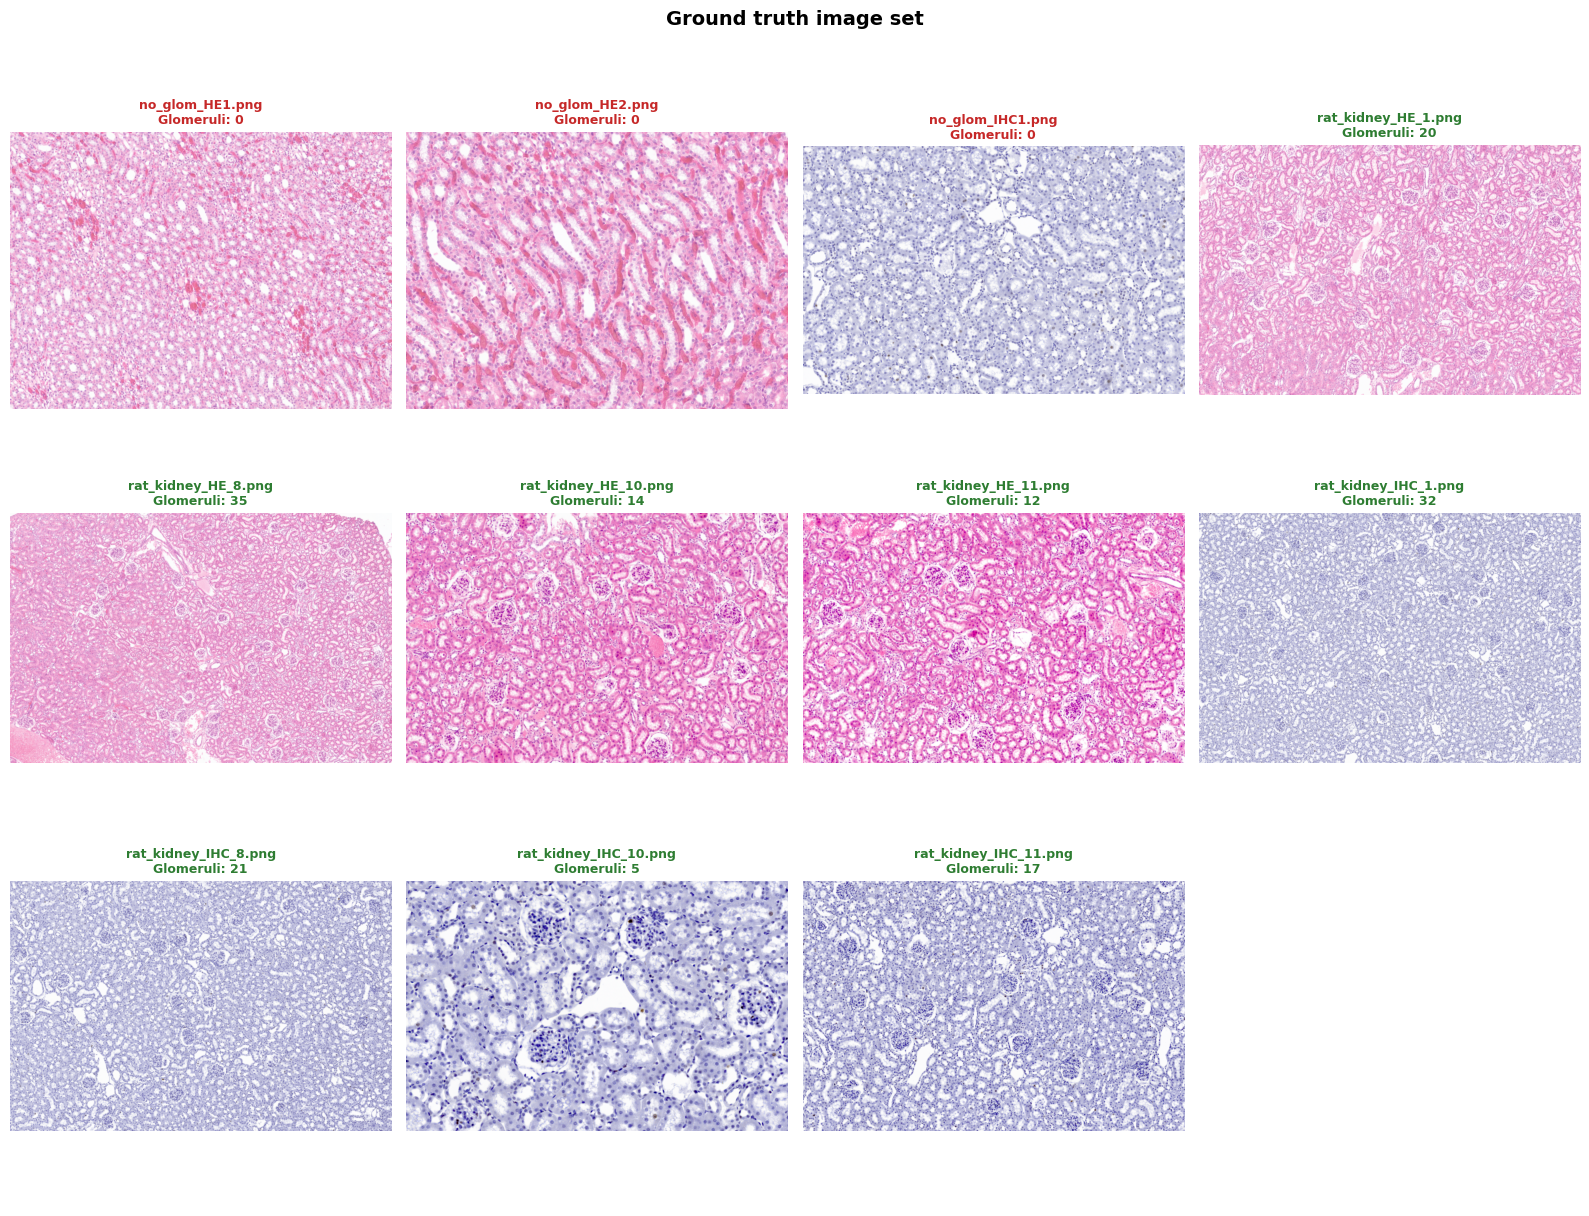

In [45]:
# Display image grid with ground truth labels
n      = len(df_gt)
ncols  = 4
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, (_, row) in enumerate(df_gt.iterrows()):
    img_path = IMAGE_FOLDER / row['filename']
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img)
    color = '#2E7D32' if row['has_glomeruli'] else '#C62828'
    label = f"{row['filename']}\nGlomeruli: {row['glomeruli_count']}"
    axes[i].set_title(label, fontsize=9, color=color, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Ground truth image set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_FOLDER / 'ground_truth_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Define the shared triage prompt

Every model receives exactly the same prompt. This is the fairest comparison we can do.
The prompt asks for a strict JSON response with five fields. We also define the JSON
parser here since all models may format their output slightly differently.

In [46]:
TRIAGE_PROMPT = """Analyze this histology image and return a JSON object with exactly these fields:
{
  "has_glomeruli": <true or false>,
  "glomeruli_count_estimate": <integer, 0 if none visible>,
  "confidence": "<high, medium, or low>",
  "tissue_type": "<brief description>",
  "stain": "<H&E, IHC, or unknown>"
}

Rules:
- has_glomeruli must be true only if you can clearly identify at least one glomerulus
- confidence should reflect how certain you are about your assessment
- Return only the JSON object, no explanation, no markdown code fences
"""


def parse_json_response(text):
    """Parse JSON from model response, stripping markdown fences if present."""
    text = re.sub(r'```json|```', '', text).strip()
    # Find first { and last } to extract JSON block
    start = text.find('{')
    end   = text.rfind('}') + 1
    if start != -1 and end > start:
        text = text[start:end]
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {
            'has_glomeruli':            None,
            'glomeruli_count_estimate': None,
            'confidence':               'error',
            'tissue_type':              None,
            'stain':                    None,
            'parse_error':              text[:200],
        }

print('Triage prompt and parser ready.')

Triage prompt and parser ready.


## Step 4: Inference functions

One function per backend: OpenAI, Anthropic, and Ollama. All take the same arguments
and return the same dict format so the main benchmark loop stays clean.

A unified `run_inference` dispatcher routes each model to the right function
based on the model registry defined in Step 1.

In [47]:
import requests

def infer_ollama(model_id, prompt, b64, timeout=300):
    """Call local Ollama vision API."""
    payload  = {'model': model_id, 'prompt': prompt, 'images': [b64], 'stream': False}
    response = requests.post(
        f'{OLLAMA_BASE_URL}/api/generate',
        json=payload, timeout=timeout,
    )
    response.raise_for_status()
    return response.json()['response']


def run_inference(model_key, prompt, b64, media_type):
    """
    Dispatcher: routes to Ollama for local models.
    Pre-filled models (claude, gpt4o) are loaded from CSV and never reach this function.
    """
    cfg      = MODELS[model_key]
    backend  = cfg['type']
    model_id = cfg['model_id']

    try:
        if backend == 'ollama':
            raw = infer_ollama(model_id, prompt, b64)
        else:
            raise ValueError(f'Backend {backend} is pre-filled from CSV, not called live.')
        return parse_json_response(raw)
    except Exception as e:
        return {
            'has_glomeruli':            None,
            'glomeruli_count_estimate': None,
            'confidence':               'error',
            'tissue_type':              None,
            'stain':                    None,
            'error':                    str(e),
        }


print('Inference functions ready (Ollama only — API models loaded from CSV).')

Inference functions ready (Ollama only — API models loaded from CSV).


## Step 5: Check Ollama models are available

Before running the full benchmark, confirm all local models are downloaded
and Ollama is running. If any are missing, pull them before continuing.

In [48]:
try:
    r = requests.get(f'{OLLAMA_BASE_URL}/api/tags', timeout=5)
    available = [m['name'] for m in r.json().get('models', [])]
    print(f'Ollama is running. Available models:')
    for m in available:
        print(f'  {m}')
    print()

    # Check each local model in registry
    for key, cfg in MODELS.items():
        if cfg['type'] == 'ollama':
            found = any(cfg['model_id'] in m for m in available)
            status = 'OK' if found else 'MISSING — run: ollama pull ' + cfg['model_id']
            print(f'  {key:15s} ({cfg["model_id"]}): {status}')

except Exception as e:
    print(f'Ollama not reachable: {e}')
    print('Start Ollama with: ollama serve')

Ollama is running. Available models:
  llava:13b
  llava:7b
  medgemma:4b
  llama3.2:latest

  medgemma_4b     (medgemma:4b): OK
  llava_7b        (llava:7b): OK
  llava_13b       (llava:13b): OK


## Step 6: Run the benchmark

This is the main loop. For each model, we run the triage prompt on every image
and collect results. Results are saved to a per-model CSV in the results/ folder
as we go, so if a model crashes mid-run we do not lose earlier results.

Local models (Ollama) are slower — expect 30 to 90 seconds per image depending
on model size and GPU. The API models are much faster.

You can run individual model cells below rather than all at once if you prefer
to control the order or skip a specific model.

In [49]:
def run_model_benchmark(model_key):
    """
    Run triage on all images for a single model.
    Returns a DataFrame with results and saves a CSV.
    """
    print(f'\n{"="*60}')
    print(f'Running: {model_key}  ({MODELS[model_key]["model_id"]})')
    print(f'{"="*60}')

    records = []
    for _, row in df_gt.iterrows():
        filename = row['filename']
        if filename not in image_cache:
            print(f'  SKIP {filename} — not in cache')
            continue

        b64        = image_cache[filename]['b64']
        media_type = image_cache[filename]['media_type']

        t0     = time.time()
        result = run_inference(model_key, TRIAGE_PROMPT, b64, media_type)
        elapsed = time.time() - t0

        result['filename']  = filename
        result['model']     = model_key
        result['elapsed_s'] = round(elapsed, 1)
        records.append(result)

        has  = result.get('has_glomeruli')
        cnt  = result.get('glomeruli_count_estimate')
        conf = result.get('confidence', 'unknown')
        print(f'  {filename:35s}  glomeruli={str(has):5}  count={str(cnt):4}  conf={conf:6}  ({elapsed:.1f}s)')

    df = pd.DataFrame(records)
    out_path = RESULTS_FOLDER / f'{model_key}_results.csv'
    df.to_csv(out_path, index=False)
    print(f'\nSaved: {out_path}')
    return df


# Storage for all model results
#all_results = {}
print('Benchmark helper ready. Run each model cell below.')

Benchmark helper ready. Run each model cell below.


In [50]:
# GPT-4o and Claude results are pre-loaded from ground_truth.csv
# No API call needed — results injected into all_results in Step 2
print('GPT-4o and Claude results already loaded from CSV.')
print(f'  GPT-4o:        {len(all_results["gpt4o"])} rows')
print(f'  Claude Sonnet: {len(all_results["claude"])} rows')

GPT-4o and Claude results already loaded from CSV.
  GPT-4o:        11 rows
  Claude Sonnet: 11 rows


In [51]:
# Conversational prompt for local models — works better than strict JSON
# for smaller models that struggle with schema instructions

LOCAL_PROMPT = """You are analyzing a kidney histology image.
Answer these questions:
1. Do you see any glomeruli? Answer yes or no.
2. How many glomeruli do you count? Answer with a number only.
3. How confident are you in your answers? Answer high, medium, or low.
4. What staining technique is used? Answer H&E, IHC, or unknown.

Answer each question on a separate line starting with the number."""


def parse_conversational_response(text):
    """Parse numbered list response into standard result dict."""
    lines = [l.strip() for l in text.strip().split('\n') if l.strip()]
    result = {
        'has_glomeruli':            None,
        'glomeruli_count_estimate': None,
        'confidence':               'low',
        'tissue_type':              'kidney',
        'stain':                    'unknown',
    }
    for idx, line in enumerate(lines[:4]):
        clean = re.sub(r'^[\d]+[\.\):\s]+', '', line).strip().lower()
        if idx == 0:
            result['has_glomeruli'] = 'yes' in clean
        elif idx == 1:
            nums = re.findall(r'\d+', clean)
            result['glomeruli_count_estimate'] = int(nums[0]) if nums else 0
        elif idx == 2:
            if 'high' in clean:
                result['confidence'] = 'high'
            elif 'medium' in clean:
                result['confidence'] = 'medium'
            else:
                result['confidence'] = 'low'
        elif idx == 3:
            if 'ihc' in clean or 'immuno' in clean:
                result['stain'] = 'IHC'
            elif 'h&e' in clean or 'hematoxylin' in clean:
                result['stain'] = 'H&E'
    return result


def run_local_model_benchmark(model_key):
    """Run benchmark for a local Ollama model using conversational prompt."""
    model_id = MODELS[model_key]['model_id']
    print(f'\n{"="*60}')
    print(f'Running: {model_key}  ({model_id})')
    print(f'{"="*60}')

    records = []
    for _, row in df_gt.iterrows():
        filename = row['filename']
        b64      = image_cache[filename]['b64']

        payload = {
            'model':  model_id,
            'prompt': LOCAL_PROMPT,
            'images': [b64],
            'stream': False,
        }
        t0 = time.time()
        try:
            r       = requests.post(f'{OLLAMA_BASE_URL}/api/generate',
                                    json=payload, timeout=120)
            r.raise_for_status()
            result  = parse_conversational_response(r.json()['response'])
        except Exception as e:
            result  = {
                'has_glomeruli': None, 'glomeruli_count_estimate': None,
                'confidence': 'error', 'tissue_type': None, 'stain': None,
                'error': str(e),
            }
        elapsed = time.time() - t0

        result['filename']  = filename
        result['model']     = model_key
        result['elapsed_s'] = round(elapsed, 1)
        records.append(result)

        has  = result.get('has_glomeruli')
        cnt  = result.get('glomeruli_count_estimate')
        conf = result.get('confidence', 'unknown')
        print(f'  {filename:35s}  glomeruli={str(has):5}  count={str(cnt):4}  conf={conf:6}  ({elapsed:.1f}s)')

    df = pd.DataFrame(records)
    df.to_csv(RESULTS_FOLDER / f'{model_key}_results.csv', index=False)
    print(f'\nSaved: results/{model_key}_results.csv')
    return df


# Run all three local models
all_results['medgemma_4b'] = run_local_model_benchmark('medgemma_4b')
all_results['llava_7b']    = run_local_model_benchmark('llava_7b')
all_results['llava_13b']   = run_local_model_benchmark('llava_13b')


Running: medgemma_4b  (medgemma:4b)
  no_glom_HE1.png                      glomeruli=True   count=2     conf=high    (13.2s)
  no_glom_HE2.png                      glomeruli=True   count=2     conf=high    (3.4s)
  no_glom_IHC1.png                     glomeruli=True   count=2     conf=high    (3.4s)
  rat_kidney_HE_1.png                  glomeruli=True   count=2     conf=high    (3.7s)
  rat_kidney_HE_8.png                  glomeruli=True   count=2     conf=high    (3.4s)
  rat_kidney_HE_10.png                 glomeruli=True   count=10    conf=high    (3.4s)
  rat_kidney_HE_11.png                 glomeruli=True   count=3     conf=high    (3.4s)
  rat_kidney_IHC_1.png                 glomeruli=True   count=2     conf=medium  (3.7s)
  rat_kidney_IHC_8.png                 glomeruli=True   count=2     conf=high    (3.6s)
  rat_kidney_IHC_10.png                glomeruli=True   count=2     conf=high    (3.4s)
  rat_kidney_IHC_11.png                glomeruli=True   count=6     conf=high    (

### Note on MedGemma 4B results

MedGemma 4B consistently returned incorrect classifications with high confidence.
Further investigation showed the model cannot visually distinguish glomeruli from 
renal tubules - it described glomeruli in images containing none, and missed them 
in images where they were clearly present.

This is likely a parameter count limitation rather than a training data issue. 
MedGemma 27B would be worth testing on a larger GPU. The results here reflect 
what a 4B medical model can realistically do on a fine-grained histopathology task.

## Step 7: Combine results with ground truth

We merge all model results into a single DataFrame alongside the ground truth values.
This is the table we use for all evaluation metrics.

If you ran models in separate sessions and have CSV files saved, you can reload
them here without re-running the benchmark.

In [52]:
# Load from saved CSVs if all_results is empty (e.g. resumed session)
for model_key in MODELS:
    csv_path = RESULTS_FOLDER / f'{model_key}_results.csv'
    if model_key not in all_results and csv_path.exists():
        all_results[model_key] = pd.read_csv(csv_path)
        print(f'Loaded from file: {csv_path}')

# Merge everything with ground truth
combined_rows = []
for model_key, df_model in all_results.items():
    for _, row in df_model.iterrows():
        gt_row = df_gt[df_gt['filename'] == row['filename']]
        if gt_row.empty:
            continue
        combined_rows.append({
            'filename':           row['filename'],
            'model':              model_key,
            'gt_has_glomeruli':   bool(gt_row.iloc[0]['has_glomeruli']),
            'gt_count':           int(gt_row.iloc[0]['glomeruli_count']),
            'pred_has_glomeruli': row.get('has_glomeruli'),
            'pred_count':         row.get('glomeruli_count_estimate'),
            'confidence':         row.get('confidence', 'unknown'),
            'stain':              row.get('stain', 'unknown'),
            'elapsed_s':          row.get('elapsed_s', None),
        })

df_combined = pd.DataFrame(combined_rows)

# Normalize stain labels to H&E or IHC
def normalize_stain(s):
    if not isinstance(s, str):
        return 'unknown'
    s = s.lower()
    if 'ihc' in s or 'immunohisto' in s:
        return 'IHC'
    if 'h&e' in s or 'hematoxylin' in s or 'he' in s:
        return 'H&E'
    return 'unknown'

df_combined['stain_normalized'] = df_combined['stain'].apply(normalize_stain)

# Add ground truth stain from filename
def gt_stain_from_filename(fn):
    fn = fn.lower()
    if 'ihc' in fn:
        return 'IHC'
    return 'H&E'

df_combined['gt_stain'] = df_combined['filename'].apply(gt_stain_from_filename)

print(f'Combined DataFrame: {len(df_combined)} rows ({len(MODELS)} models x {len(df_gt)} images)')
display(df_combined.head(10))

Combined DataFrame: 55 rows (5 models x 11 images)


,filename,model,gt_has_glomeruli,gt_count,pred_has_glomeruli,pred_count,confidence,stain,elapsed_s,stain_normalized,gt_stain
0,no_glom_HE1.png,claude,False,0,False,0,high,H&E,NaN,H&E,H&E
1,no_glom_HE2.png,claude,False,0,False,0,high,H&E,NaN,H&E,H&E
2,no_glom_IHC1.png,claude,False,0,False,0,high,IHC,NaN,IHC,IHC
3,rat_kidney_HE_1.png,claude,True,20,True,18,high,H&E,NaN,H&E,H&E
4,rat_kidney_HE_8.png,claude,True,35,True,35,high,H&E,NaN,H&E,H&E
5,rat_kidney_HE_10.png,claude,True,14,True,12,high,H&E,NaN,H&E,H&E
6,rat_kidney_HE_11.png,claude,True,12,True,8,high,H&E,NaN,H&E,H&E
7,rat_kidney_IHC_1.png,claude,True,32,True,18,high,IHC,NaN,IHC,IHC
8,rat_kidney_IHC_8.png,claude,True,21,True,12,high,IHC,NaN,IHC,IHC
9,rat_kidney_IHC_10.png,claude,True,5,True,6,high,IHC,NaN,IHC,IHC


## Step 8: Evaluate each model

We compute four metrics per model:

1. **Classification accuracy** — correct has_glomeruli predictions / total images
2. **Count MAE** — mean absolute error on glomeruli count for positive images
3. **High-confidence accuracy** — accuracy on images where the model said high confidence
4. **Stain recognition accuracy** — correct H&E vs IHC identification

We also record average inference time per image for each model.

In [53]:
eval_rows = []

for model_key in MODELS:
    df_m = df_combined[df_combined['model'] == model_key].copy()
    if df_m.empty:
        continue

    # Drop rows where prediction failed
    df_valid = df_m[df_m['pred_has_glomeruli'].notna()].copy()
    df_valid['pred_has_glomeruli'] = df_valid['pred_has_glomeruli'].astype(bool)

    # 1. Classification accuracy
    correct = (df_valid['pred_has_glomeruli'] == df_valid['gt_has_glomeruli']).sum()
    cls_acc = correct / len(df_valid) if len(df_valid) > 0 else 0

    # 2. Count MAE on positive images only
    df_pos = df_valid[
        df_valid['gt_has_glomeruli'] &
        df_valid['pred_count'].notna()
    ].copy()
    df_pos['pred_count'] = pd.to_numeric(df_pos['pred_count'], errors='coerce')
    df_pos = df_pos[df_pos['pred_count'].notna()]
    count_mae = float(np.abs(df_pos['pred_count'] - df_pos['gt_count']).mean()) \
        if len(df_pos) > 0 else None

    # 3. High-confidence accuracy
    df_high = df_valid[df_valid['confidence'] == 'high']
    high_acc = (df_high['pred_has_glomeruli'] == df_high['gt_has_glomeruli']).mean() \
        if len(df_high) > 0 else None
    n_high = len(df_high)

    # 4. Stain recognition accuracy
    stain_acc = (df_valid['stain_normalized'] == df_valid['gt_stain']).mean()

    # 5. Average inference time
    avg_time = df_m['elapsed_s'].mean() if 'elapsed_s' in df_m.columns else None

    eval_rows.append({
        'model':           model_key,
        'n_images':        len(df_valid),
        'cls_accuracy':    round(cls_acc, 3),
        'count_mae':       round(count_mae, 2) if count_mae is not None else None,
        'high_conf_acc':   round(high_acc, 3) if high_acc is not None else None,
        'n_high_conf':     n_high,
        'stain_acc':       round(stain_acc, 3),
        'avg_time_s':      round(avg_time, 1) if avg_time is not None else None,
    })

df_eval = pd.DataFrame(eval_rows).set_index('model')
df_eval.to_csv(RESULTS_FOLDER / 'evaluation_summary.csv')

print('Evaluation summary:')
display(df_eval)

Evaluation summary:


,n_images,cls_accuracy,count_mae,high_conf_acc,n_high_conf,stain_acc,avg_time_s
model,,,,,,,
gpt4o,11,0.909,10.12,0.9,10,1.000,NaN
claude,11,1.000,4.62,1.0,11,1.000,NaN
medgemma_4b,11,0.727,15.88,0.7,10,0.545,4.4
llava_7b,11,0.818,13.75,0.8,5,0.273,3.6
llava_13b,11,0.727,16.12,0.5,2,0.364,4.0


## Step 9: Visualize results

Four charts, one per metric, arranged in a 2x2 grid. Color-coded by model type:
API models in blue and green, local models in purple and orange.

We also show a per-image heatmap so you can see exactly where each model succeeded
or failed at the image level.

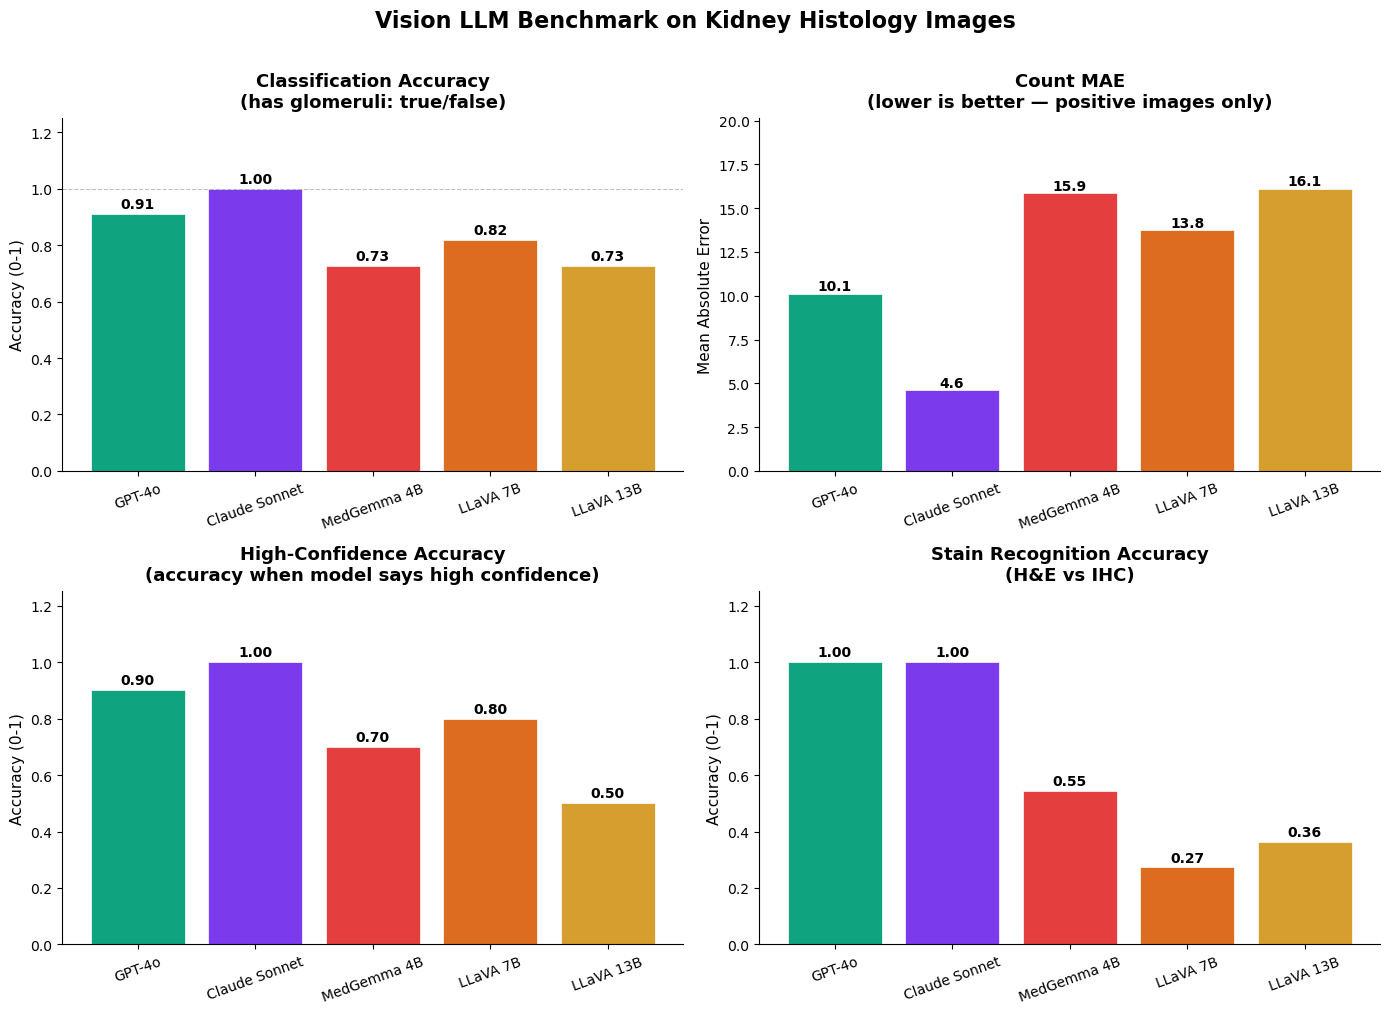

Saved: results/benchmark_charts.png


In [54]:
# Color palette consistent with slides
MODEL_COLORS = {
    'gpt4o':       '#10A37F',
    'claude':      '#7C3AED',
    'medgemma_4b': '#E53E3E',
    'llava_7b':    '#DD6B20',
    'llava_13b':   '#D69E2E',
}

MODEL_LABELS = {
    'gpt4o':       'GPT-4o',
    'claude':      'Claude Sonnet',
    'medgemma_4b': 'MedGemma 4B',
    'llava_7b':    'LLaVA 7B',
    'llava_13b':   'LLaVA 13B',
}

models_in_eval = [m for m in MODELS if m in df_eval.index]
labels  = [MODEL_LABELS[m] for m in models_in_eval]
colors  = [MODEL_COLORS[m] for m in models_in_eval]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Vision LLM Benchmark on Kidney Histology Images',
             fontsize=16, fontweight='bold', y=1.01)

def bar_chart(ax, values, title, ylabel, higher_is_better=True, fmt='.2f'):
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, max(v for v in values if v is not None) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:{fmt}}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Chart 1: Classification accuracy
cls_vals = [df_eval.loc[m, 'cls_accuracy'] if m in df_eval.index else 0
            for m in models_in_eval]
bar_chart(axes[0,0], cls_vals,
          'Classification Accuracy\n(has glomeruli: true/false)',
          'Accuracy (0-1)')
axes[0,0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Chart 2: Count MAE (lower is better)
mae_vals = [df_eval.loc[m, 'count_mae'] if m in df_eval.index else None
            for m in models_in_eval]
mae_plot = [v if v is not None else 0 for v in mae_vals]
bar_chart(axes[0,1], mae_plot,
          'Count MAE\n(lower is better — positive images only)',
          'Mean Absolute Error', higher_is_better=False, fmt='.1f')

# Chart 3: High-confidence accuracy
hca_vals = [df_eval.loc[m, 'high_conf_acc'] if m in df_eval.index else 0
            for m in models_in_eval]
hca_plot = [v if v is not None else 0 for v in hca_vals]
bar_chart(axes[1,0], hca_plot,
          'High-Confidence Accuracy\n(accuracy when model says high confidence)',
          'Accuracy (0-1)')

# Chart 4: Stain recognition accuracy
stain_vals = [df_eval.loc[m, 'stain_acc'] if m in df_eval.index else 0
              for m in models_in_eval]
bar_chart(axes[1,1], stain_vals,
          'Stain Recognition Accuracy\n(H&E vs IHC)',
          'Accuracy (0-1)')

plt.tight_layout()
plt.savefig(RESULTS_FOLDER / 'benchmark_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/benchmark_charts.png')

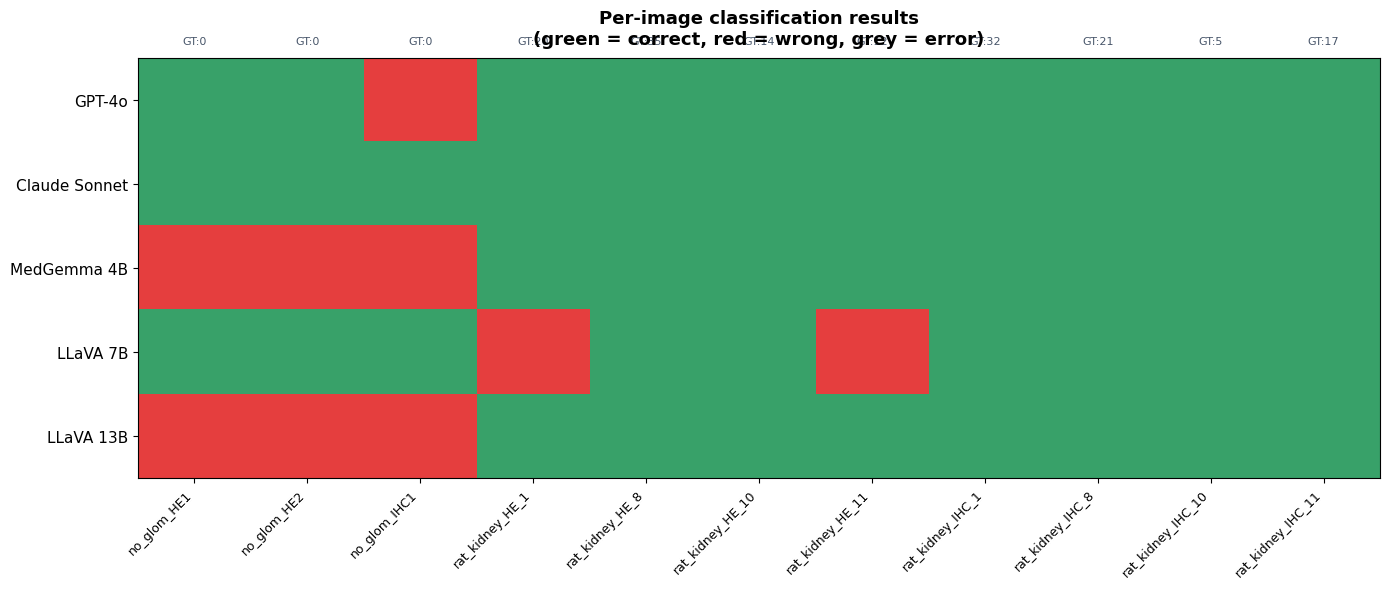

Saved: results/classification_heatmap.png


In [55]:
# Per-image classification heatmap
# Green = correct, Red = wrong, Grey = error/no prediction

filenames = df_gt['filename'].tolist()
n_models  = len(models_in_eval)
n_images  = len(filenames)

matrix = np.full((n_models, n_images), np.nan)

for i, model_key in enumerate(models_in_eval):
    df_m = df_combined[df_combined['model'] == model_key]
    for j, fname in enumerate(filenames):
        row = df_m[df_m['filename'] == fname]
        if row.empty:
            continue
        pred = row.iloc[0]['pred_has_glomeruli']
        gt   = row.iloc[0]['gt_has_glomeruli']
        if pred is None or pred != pred:  # NaN check
            matrix[i, j] = 0.5
        elif bool(pred) == bool(gt):
            matrix[i, j] = 1.0  # correct
        else:
            matrix[i, j] = 0.0  # wrong

fig, ax = plt.subplots(figsize=(max(14, n_images * 1.1), n_models * 0.9 + 1.5))

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#E53E3E', '#CBD5E0', '#38A169'])

im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(n_images))
ax.set_xticklabels([f.replace('.png','').replace('.jpg','') for f in filenames],
                   rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_models))
ax.set_yticklabels([MODEL_LABELS[m] for m in models_in_eval], fontsize=11)
ax.set_title('Per-image classification results\n(green = correct, red = wrong, grey = error)',
             fontsize=13, fontweight='bold', pad=10)

# Add GT count as column headers
for j, fname in enumerate(filenames):
    gt_row = df_gt[df_gt['filename'] == fname].iloc[0]
    ax.text(j, -0.7, f"GT:{gt_row['glomeruli_count']}",
            ha='center', va='center', fontsize=8, color='#475569')

plt.tight_layout()
plt.savefig(RESULTS_FOLDER / 'classification_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/classification_heatmap.png')

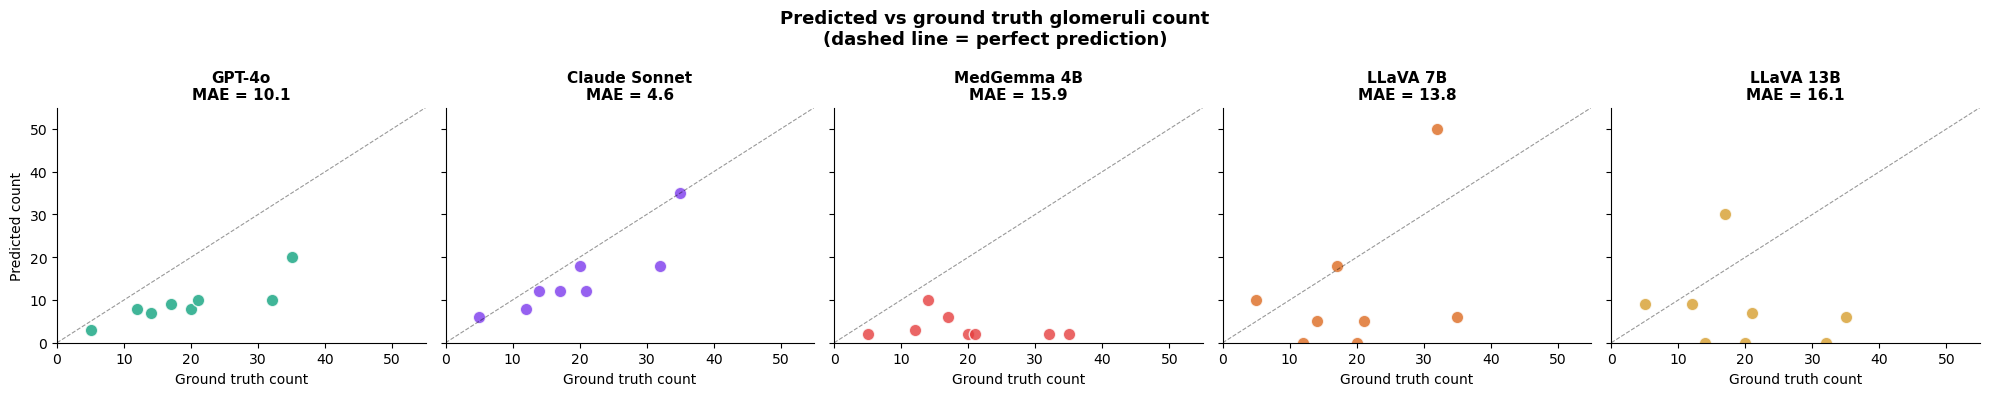

Saved: results/count_scatter.png


In [56]:
# Count estimate scatter plot — predicted vs ground truth per model
# Only for images where ground truth count > 0

df_pos_all = df_combined[
    df_combined['gt_has_glomeruli'] &
    df_combined['pred_count'].notna()
].copy()
df_pos_all['pred_count'] = pd.to_numeric(df_pos_all['pred_count'], errors='coerce')
df_pos_all = df_pos_all.dropna(subset=['pred_count'])

max_val = max(df_pos_all['gt_count'].max(), df_pos_all['pred_count'].max()) + 5

fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model_key in zip(axes, models_in_eval):
    df_m = df_pos_all[df_pos_all['model'] == model_key]
    ax.scatter(df_m['gt_count'], df_m['pred_count'],
               color=MODEL_COLORS[model_key], s=80, alpha=0.8, edgecolors='white')
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=0.8, alpha=0.4)
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Ground truth count', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Predicted count', fontsize=10)
    mae = df_eval.loc[model_key, 'count_mae'] if model_key in df_eval.index else None
    ax.set_title(f'{MODEL_LABELS[model_key]}\nMAE = {mae:.1f}' if mae else MODEL_LABELS[model_key],
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Predicted vs ground truth glomeruli count\n(dashed line = perfect prediction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_FOLDER / 'count_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/count_scatter.png')

## Step 10: Final summary table

A clean printable summary of all metrics across all models. This is the table
you would include in a methods section or a comparison slide.

In [57]:
# Rename columns for display
df_display = df_eval[[
    'cls_accuracy', 'count_mae', 'high_conf_acc', 'stain_acc', 'avg_time_s'
]].copy()

df_display.index = [MODEL_LABELS[m] for m in df_display.index]
df_display.columns = [
    'Classification Acc.',
    'Count MAE (lower better)',
    'High-Conf Acc.',
    'Stain Acc.',
    'Avg Time (s/image)',
]

print('=' * 70)
print('FINAL BENCHMARK RESULTS')
print('=' * 70)
display(df_display.style
    .format({
        'Classification Acc.':      '{:.1%}',
        'Count MAE (lower better)': '{:.1f}',
        'High-Conf Acc.':           '{:.1%}',
        'Stain Acc.':               '{:.1%}',
        'Avg Time (s/image)':       '{:.1f}',
    }, na_rep='N/A')
    .highlight_max(subset=['Classification Acc.', 'High-Conf Acc.', 'Stain Acc.'],
                   color='#C6EFCE')
    .highlight_min(subset=['Count MAE (lower better)'],
                   color='#C6EFCE')
)

df_display.to_csv(RESULTS_FOLDER / 'final_summary.csv')
print('\nSaved: results/final_summary.csv')
print()
print('Key observations:')
best_cls   = df_eval['cls_accuracy'].idxmax()
best_count = df_eval['count_mae'].idxmin()
best_stain = df_eval['stain_acc'].idxmax()
print(f'  Best classification accuracy : {MODEL_LABELS[best_cls]} ({df_eval.loc[best_cls, "cls_accuracy"]:.1%})')
print(f'  Best count estimate (MAE)    : {MODEL_LABELS[best_count]} ({df_eval.loc[best_count, "count_mae"]:.1f})')
print(f'  Best stain recognition       : {MODEL_LABELS[best_stain]} ({df_eval.loc[best_stain, "stain_acc"]:.1%})')
fastest = df_eval['avg_time_s'].idxmin()
slowest = df_eval['avg_time_s'].idxmax()
print(f'  Fastest model                : {MODEL_LABELS[fastest]} ({df_eval.loc[fastest, "avg_time_s"]:.1f}s/image)')
print(f'  Slowest model                : {MODEL_LABELS[slowest]} ({df_eval.loc[slowest, "avg_time_s"]:.1f}s/image)')

FINAL BENCHMARK RESULTS


,Classification Acc.,Count MAE (lower better),High-Conf Acc.,Stain Acc.,Avg Time (s/image)
GPT-4o,90.9%,10.1,90.0%,100.0%,N/A
Claude Sonnet,100.0%,4.6,100.0%,100.0%,N/A
MedGemma 4B,72.7%,15.9,70.0%,54.5%,4.4
LLaVA 7B,81.8%,13.8,80.0%,27.3%,3.6
LLaVA 13B,72.7%,16.1,50.0%,36.4%,4.0



Saved: results/final_summary.csv

Key observations:
  Best classification accuracy : Claude Sonnet (100.0%)
  Best count estimate (MAE)    : Claude Sonnet (4.6)
  Best stain recognition       : GPT-4o (100.0%)
  Fastest model                : LLaVA 7B (3.6s/image)
  Slowest model                : MedGemma 4B (4.4s/image)


## Conclusions

This benchmark gives us a quantitative answer to the question we posed at the start:
does domain-specific training (MedGemma) beat general-purpose frontier models
(GPT-4o, Claude) on kidney histology image analysis?

A few things to keep in mind when interpreting the results:

- Our dataset is small. With 11 images, differences of one or two correct predictions
  translate to large percentage differences. Interpret the numbers directionally
  rather than as statistically definitive.

- Count estimation is inherently subjective. Even human annotators disagree on
  glomeruli counts, especially near image edges. The MAE metric captures the
  magnitude of disagreement but not whether the model's errors are systematic.

- MedGemma 27B would likely outperform the 4B version but requires more than
  16 GB of VRAM. If you have access to a larger GPU it is worth testing.

- For production use on sensitive medical data, local models (MedGemma, LLaVA)
  are the only option since no data leaves your infrastructure.

---
*Code for this series: https://github.com/bnsreenu/llm-vision-for-scientists*

*YouTube: https://www.youtube.com/@DigitalSreeni*
